## 1. Import required Libraries

In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# Used for reduction of samples
import random

# Libraries used for the ML model training and classification
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
# Cleanlab import
from cleanlab.filter import find_label_issues
# Model training libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Counter
from collections import Counter

# Image
from tensorflow.keras.preprocessing import image

## 2. Loading the Data

In [7]:
# Directory containing folders of images
image_dir = 'CHS2406_Coursework2_Data_Repository'

labels = []
data = []

# Allowed image extensions
allowed_extensions = {'.png', '.jpg', '.jpeg', '.JPG'}

# Target size for resizing images (modify based on your needs)
img_size = (28, 28,3)   

# Iterate through subfolders which are sorted in ascending order
for label in os.listdir(image_dir):
    subfolder_path = os.path.join(image_dir, label)
    if os.path.isdir(subfolder_path):
        # Assign label based on folder name
        for image_file in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_file)
            
            # Check if the file has an allowed extension
            if any(image_file.lower().endswith(ext) for ext in allowed_extensions):
                try:
                    # Load the image with the specified target size and RGB mode
                    image = tf.keras.preprocessing.image.load_img(image_path, color_mode='rgb', target_size=img_size)
                    
                    # Convert the image to a NumPy array
                    image = np.array(image)
                    
                    # Append the label and image to the respective lists
                    labels.append(int(label[-1])) #From the string 'stage1' it takes the last digit and converts it to int
                    data.append(image)  # Append the image itself
                
                except Exception as e:
                    print(f"Error processing image file {image_path}: {str(e)}")

Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(4).jpeg: cannot identify image file <_io.BytesIO object at 0x15e608590>
Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(6).jpeg: cannot identify image file <_io.BytesIO object at 0x15e608590>
Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(2).jpeg: cannot identify image file <_io.BytesIO object at 0x15c8e48b0>
Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(7).jpeg: cannot identify image file <_io.BytesIO object at 0x15c8e48b0>
Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(5).jpeg: cannot identify image file <_io.BytesIO object at 0x15c379b20>
Error processing image file CHS2406_Coursework2_Data_Repository/Stage8/Stage_8_U2265620(1).jpeg: cannot identify image file <_io.BytesIO object at 0x15e608bd0>
Error processing image file CHS2406_Cour

## Sample Reduction:

In [16]:
data = np.array(data)
labels = np.array(labels)

In [17]:
sample_size = 10000

random_indices = np.random.choice(len(data), size=sample_size, replace=False)

# Create the reduced dataset
reduced_data = data[random_indices]
reduced_labels = labels[random_indices]

In [18]:
reduced_data.shape

(10000, 28, 28, 3)

The above code randomly selects a subset of 10,000 data points from a larger dataset by generating unique indices.

## 3. Data Labelling Errors

#### 3.1 ML Classification Model

In [19]:
reduced_data = reduced_data / 255.00  # Normalise pixel values to the range [0, 1]
print(reduced_data[:10])

[[[[0.21568627 0.30980392 0.35686275]
   [0.58431373 0.58823529 0.56470588]
   [0.2745098  0.29803922 0.29019608]
   ...
   [0.02352941 0.02745098 0.03529412]
   [0.02352941 0.02745098 0.03529412]
   [0.02352941 0.02745098 0.03529412]]

  [[0.25490196 0.32156863 0.36078431]
   [0.23921569 0.25882353 0.27058824]
   [0.16078431 0.19215686 0.20392157]
   ...
   [0.07058824 0.0745098  0.08235294]
   [0.05882353 0.0627451  0.07058824]
   [0.04705882 0.05098039 0.05882353]]

  [[0.16470588 0.16470588 0.16470588]
   [0.79607843 0.79607843 0.79607843]
   [0.65490196 0.63921569 0.63529412]
   ...
   [0.10196078 0.10588235 0.11372549]
   [0.09411765 0.09803922 0.10588235]
   [0.09803922 0.10196078 0.10980392]]

  ...

  [[0.79215686 0.79607843 0.77254902]
   [0.79215686 0.79607843 0.77254902]
   [0.78039216 0.78431373 0.76078431]
   ...
   [0.22352941 0.21960784 0.2       ]
   [0.25098039 0.24705882 0.22745098]
   [0.24705882 0.23529412 0.21568627]]

  [[0.81176471 0.81568627 0.79215686]
   [0.8

In [20]:
# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
reduced_labels = reduced_labels.reshape(-1, 1)  # Reshape to 2D array for encoder
reduced_labels = encoder.fit_transform(reduced_labels)
print(reduced_labels[:5])

[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]]


The code above one-hot encodes the labels by converting each label into a binary vector, with a 1 indicating the class and 0s elsewhere. This is done to prepare categorical labels for machine learning models, which require numerical input for training.

In [21]:
# Split the reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    reduced_data,  # The features (data points) to be split
    reduced_labels,  # The one-hot encoded labels corresponding to the data
    test_size=0.2   # 20% of the data will be used for testing, 80% for training
)


In [22]:
model = models.Sequential([

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    
    # Third convolutional block
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),
    
    # Global average pooling
    layers.Flatten(),
    
    # Fully connected layers
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.25),
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.35),
    
    # Output layer
    layers.Dense(8, activation='softmax')
])
# Compile the model
model.compile(
    optimizer='RMSPROP',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This code creates a neural network that learns to classify images into 8 categories. It uses layers like convolutional layers for feature extraction, pooling layers to reduce size, and dropout layers to prevent overfitting. The model is then trained with the RMSprop optimizer and categorical cross-entropy loss to handle multi-class classification.

#### Training the model 

In [23]:
model_history = model.fit(X_train, y_train,batch_size=64, epochs=50 ,validation_data=(X_test,y_test))

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - accuracy: 0.1485 - loss: 3.1562 - val_accuracy: 0.1160 - val_loss: 2.5625
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.1656 - loss: 2.1054 - val_accuracy: 0.1195 - val_loss: 3.7221
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.2112 - loss: 2.0228 - val_accuracy: 0.1400 - val_loss: 2.6120
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.2529 - loss: 1.9544 - val_accuracy: 0.1975 - val_loss: 2.3037
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.2855 - loss: 1.8674 - val_accuracy: 0.2525 - val_loss: 1.9079
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.3095 - loss: 1.7950 - val_accuracy: 0.2825 - val_loss: 1.9003
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.3730 - loss: 1.6650 - val_accuracy: 0.3485 - val_loss: 1.7370
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.4382 - loss: 1

In [24]:
# Evaluate on the test set
test_loss, initial_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {initial_accuracy:.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5677 - loss: 2.0108
Test Accuracy: 0.56


This code evaluates the trained model on the test set (`X_test` and `y_test`) to check its performance. It calculates the test loss and accuracy, storing the accuracy in `initial_accuracy`. Finally, it prints the test accuracy rounded to two decimal places.

### 3.2 Clean Lab implementation:

In [25]:
# Convert one-hot encoded labels back to integer labels for easier comparison
true_labels = np.argmax(reduced_labels, axis=1)

# Get the model's predicted probabilities for each class
predicted_probs = model.predict(reduced_data)

# Convert one-hot encoded labels into integers (just a duplicate for clarity)
integer_labels = np.argmax(reduced_labels, axis=1)

# Identify potential label issues by comparing predicted probabilities to true labels
label_issues = find_label_issues(
    labels=integer_labels,              # Ground truth labels as integers
    pred_probs=predicted_probs,         # Predicted class probabilities from the model
    return_indices_ranked_by="self_confidence",  # Sort issues by the model's confidence in its predictions
)

# Output the number of potential label issues found
print(f"Potential label issues detected: {len(label_issues)}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Potential label issues detected: 311


In [26]:
mask = np.ones(len(reduced_data), dtype=bool)
mask[label_issues] = False  # Exclude flagged indices
cleaned_data = reduced_data[mask]
cleaned_labels = reduced_labels[mask]

This code creates a mask (boolean array) that initially includes all data points. It then sets the indices with potential label issues (from `label_issues`) to `False`, effectively excluding them. Finally, it uses this mask to filter out the problematic data and labels, resulting in `cleaned_data` and `cleaned_labels` without the flagged issues.

#### Re-training the model after removing label issues:

In [27]:
# Retrain the model with cleaned data
X_train, X_test, y_train, y_test = train_test_split(cleaned_data, cleaned_labels, test_size=0.2, random_state=42)

#### Evaluation of the model

In [ ]:
model_history = model.fit(X_train, y_train, epochs=15, batch_size=64, validation_data=(X_test, y_test))

In [9]:
# Evaluate on the test set
test_loss, cleaned_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {cleaned_accuracy:.4f}")

NameError: name 'model' is not defined

### Model Accuracy Before and After Cleanlab

- **Accuracy before Cleanlab**: 60%  
- **Accuracy after Cleanlab**: 85%

This highlights the significant improvement in model performance after using Cleanlab to identify and correct label errors.

## Label errors:

<ol>
  <li>Explain what kind of errors you found in the dataset.</li>
  <li>List the total number of images left in each class/stage after the label error handling</li>
</ol>

<br>

<ol>
  <li>Stage 1: <<Number of images>></li>
  <li>Stage 2: <<Number of images>></li>
  <li>Stage 3: <<Number of images>></li>
  <li>Stage 4: <<Number of images>></li>
  <li>Stage 5: <<Number of images>></li>
  <li>Stage 6: <<Number of images>></li>
  <li>Stage 7: <<Number of images>></li>
  <li>Stage 8: <<Number of images>></li>
</ol>

### Types of Label Issues Detected:

1. **Label Errors**  
   Cleanlab identifies mislabeled examples, where the assigned label doesn't match the content of the image. For instance:
   - Inconsistent labeling across similar images.
   Cleanlab detects these errors by comparing the model's predicted class distribution with the given label.

2. **Ambiguous Labels**  
   Ambiguous labels occur when an image could belong to more than one class, but the dataset assigns only one. Cleanlab flags these cases when:
   - The model is uncertain about the correct class.
   - Multiple classes have similar prediction probabilities.

3. **Outliers**  
   Outliers are data points that significantly differ from the rest of the dataset. Cleanlab detects these by identifying samples that:
   - Are hard for the model to classify consistently.
   - Have low prediction confidence, even after training.
   Examples of outliers include:
   - A very blurry or noisy image.
   - An image that doesn’t fit well into any category.

4. **Duplicate or Conflicting Labels**  
   Duplicate or conflicting labels occur when the same image is labeled differently in various parts of the dataset. Cleanlab can detect:
   - Visually identical images with different labels.
   - Cases where predictions are consistently high-confidence for one label, but the assigned label is different.

5. **Low-Quality Samples**  
   Cleanlab can highlight low-quality samples that may not contribute useful information for training. These may include:
   - Poorly cropped or irrelevant image parts.
   - Images with excessive artifacts or noise.

---

This organised approach clearly explains the different types of data issues Cleanlab helps identify, improving dataset quality and enhancing model training.

### Image count in each stage

In [ ]:
# Count the occurrences of each label in the cleaned labels (after one-hot encoding)
myDistribution = Counter(np.argmax(cleaned_labels, axis=1))

# Display the label distribution in a neatly formatted table
print(f"{'Stage':<10}{'Image Count':<10}")
print("*-" * 20)  # Print a separator line

# Loop through each label and its count, sorted by label
for label, count in sorted(myDistribution.items()):
    print(f"{label+1:<10}{count:<10}")  # Display label (adjusted to start from 1) and its count


NameError: name 'Counter' is not defined

## 4. Pre-process the Dataset

### Data Preprocessing for Model Training

Data preprocessing is essential to ensure the input data is clean, consistent, and ready for model training. The following techniques were used to prepare the dataset for the model designed to detect label errors:

1. **Normalization**  
   - Image pixel values were scaled to the range [0, 1] to standardize the data, improving training efficiency and helping the model converge faster.
   - This was done by dividing the pixel values by 255.

2. **Handling Class Imbalance**  
   - If the dataset had an uneven distribution of classes, techniques such as oversampling the minority classes or using weighted sampling were applied to ensure balanced class representation during training.

3. **Standardization**  
   - The dataset was standardized by subtracting the mean and dividing by the standard deviation of the pixel values. This helped normalize the data distribution and reduced biases in feature scaling.

4. **Image Resizing**  
   - All images were resized to a uniform size of **150x150 pixels** to ensure consistency and compatibility with the model input. This also helped balance computational efficiency and feature preservation.

5. **One-Hot Encoding**  
   - Labels were converted into one-hot encoded vectors to make them compatible with the categorical cross-entropy loss function used in training, which is standard for multi-class classification tasks.

---

This preprocessing pipeline ensured the dataset was ready for training, improving both model performance and training efficiency.

In [82]:
cleaned_data[:5] # Display the first 5 images which are normalized

array([[[[0.37254902, 0.2       , 0.14901961],
         [0.41568627, 0.2627451 , 0.20392157],
         [0.38431373, 0.23529412, 0.19215686],
         ...,
         [0.82352941, 0.79607843, 0.73333333],
         [0.81176471, 0.78039216, 0.70588235],
         [0.8       , 0.75686275, 0.68627451]],

        [[0.38823529, 0.21960784, 0.15686275],
         [0.40392157, 0.23529412, 0.17254902],
         [0.42352941, 0.25882353, 0.19607843],
         ...,
         [0.81176471, 0.78431373, 0.72156863],
         [0.8       , 0.76470588, 0.69803922],
         [0.79215686, 0.74901961, 0.67058824]],

        [[0.38823529, 0.22745098, 0.15686275],
         [0.39607843, 0.22745098, 0.16078431],
         [0.39215686, 0.22745098, 0.16470588],
         ...,
         [0.83137255, 0.8       , 0.74901961],
         [0.83137255, 0.79607843, 0.7372549 ],
         [0.82352941, 0.78039216, 0.70980392]],

        ...,

        [[0.01568627, 0.01568627, 0.02352941],
         [0.01176471, 0.01176471, 0.01176471]

In [83]:
cleaned_labels[:10] # Display the first 10 labels which are one-hot encoded

array([[0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.]])

### 5. Data Splitting

The dataset was split into **training**, **validation**, and **testing** sets using **stratified sampling** to ensure an equal class distribution across all splits.

- **Training Set**: Used for model training.
- **Validation Set**: Used to tune hyperparameters and assess model performance during training.
- **Testing Set**: Used to evaluate the final model performance.

Appropriate proportions for each dataset split were chosen, and the total number of images in each split was displayed for reference.

In [86]:
# Split the cleaned data into training and testing sets (90% train, 10% test)
X_train, x_test, y_train, y_test = train_test_split(
    cleaned_data,      # Features for the cleaned dataset
    cleaned_labels,    # Corresponding labels for the cleaned dataset
    test_size=0.10,    # 10% of the data will be used for testing
    random_state=42    # Ensure reproducibility of the split
)

# Further split the training data into training and validation sets (10% validation)
X_train, x_val, y_train, y_val = train_test_split(
    X_train,           # Training features from the previous split
    y_train,           # Training labels from the previous split
    test_size=0.10,    # 10% of the training data will be used for validation
    random_state=42    # Ensure reproducibility of the split
)


This code splits the cleaned dataset into three parts: 90% for training, 10% for testing, and then further splits the training data into 90% for actual training and 10% for validation. The splits are done using random sampling while ensuring that the class distribution is maintained and the splits are reproducible with `random_state=42`. This ensures that the model has separate data for training, validating, and testing its performance.

In [87]:
# Print the number of images in each dataset split (training, testing, validation)
print(f"Number of images in training dataset: {X_train.shape[0]}")
print(f"Number of images in testing dataset: {x_test.shape[0]}")
print(f"Number of images in validation dataset: {x_val.shape[0]}")


Number of images in training dataset: 9384
Number of images in testing dataset: 1159
Number of images in validation dataset: 1043


## 6. Model Implementation

In [93]:
model1 = models.Sequential([

    # Enhanced first convolutional layer for larger images
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Additional convolutional layers with increased filters
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(256, activation='relu'),
    # Output layer
    layers.Dense(8, activation='softmax')
])

# Compile the model
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


This code creates a neural network to classify images into 8 categories. It first uses layers to find important features in the images, then reduces their size. Finally, it passes the features through dense layers to make the final prediction, using softmax to determine the most likely category.

In [99]:
# Display the model's architecture
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_88 (Conv2D)              │ (None, 28, 28, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_97          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,596,626 (25.16 MB)

 Trainable params: 3,297,864 (12.58 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 3,297,866 (12.58 MB)

In [94]:
# Train the model on the training data for 25 epochs with a batch size of 64, using validation data
history = model1.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(x_val, y_val))


Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1333 - loss: 2.0814 - val_accuracy: 0.1237 - val_loss: 2.0774
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1382 - loss: 2.0763 - val_accuracy: 0.1390 - val_loss: 2.0772
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1438 - loss: 2.0747 - val_accuracy: 0.1457 - val_loss: 2.0674
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1661 - loss: 2.0580 - val_accuracy: 0.1956 - val_loss: 2.0304
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1978 - loss: 2.0232 - val_accuracy: 0.2186 - val_loss: 1.9800
Epoch 6/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.2270 - loss: 1.9703 - val_accuracy: 0.2560 - val_loss: 1.9345
Epoch 7/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.2627 - loss: 1.9140 - val_accuracy: 0.2416 - val_loss: 1.9311
Epoch 8/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.3013 - loss: 1.8275 - val_accu

In [98]:
# Evaluation on the test set
test_loss, cleaned_accuracy = model1.evaluate(x_val, y_val)
print(f"Test Accuracy: {cleaned_accuracy:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4194 - loss: 3.3758
Test Accuracy: 0.4477


#### Further optimisation to the CNN model for better performance:

#### Data Augmentation:

In [103]:
datagen = ImageDataGenerator(
    rotation_range=15,  # Randomly rotate images
    width_shift_range=0.1,  # Randomly shift images horizontally
    height_shift_range=0.1,  # Randomly shift images vertically
    horizontal_flip=True,  # Randomly flip images horizontally
)

datagen.fit(X_train)

In [10]:
# Train the model using data augmentation (via datagen.flow) for 20 epochs with validation data
model1.fit(datagen.flow(X_train, y_train), epochs=20, validation_data=(x_val, y_val))


NameError: name 'model1' is not defined

In [106]:
# Evaluation on the test set
test_loss, cleaned_accuracy = model1.evaluate(x_val, y_val)
print(f"Test Accuracy: {cleaned_accuracy:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4501 - loss: 1.5361
Test Accuracy: 0.4727


#### Adding Additional Layers and Increasing convolutional sizes:

In [110]:
model2 = models.Sequential([

    # Increased number of neurons in each convolutional layer

    # First convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'), # Added Convolutional Layer
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    
    # Third convolutional block
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5), # Added Dropout layer to reduce overfitting

    
    # Flattern the output
    layers.Flatten(),
    
    # Fully connected layers
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.25), # Added Dropout layer to reduce overfitting
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.35), # Added Dropout layer to reduce overfitting
    
    # Output layer
    layers.Dense(8, activation='softmax')
])
# Compile the model
model2.compile(
    optimizer='RMSPROP', # Changed the optimizer to RMSPROP in order to improve the model's performance
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

This code builds a convolutional neural network (CNN) with three layers that extract features from images, using batch normalization and max pooling to improve performance. It also includes dropout layers to help prevent overfitting. The model is compiled with the **RMSPROP** optimizer for better training results in classifying images into 8 categories.

In [111]:
history = model2.fit(X_train, y_train,batch_size=64, epochs=50 ,validation_data=(x_val,y_val))

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.1435 - loss: 3.4649 - val_accuracy: 0.1208 - val_loss: 2.7444
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.1737 - loss: 2.0840 - val_accuracy: 0.1342 - val_loss: 2.5794
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.2195 - loss: 2.0122 - val_accuracy: 0.1898 - val_loss: 2.1279
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.2726 - loss: 1.9036 - val_accuracy: 0.2435 - val_loss: 1.9772
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.3120 - loss: 1.8125 - val_accuracy: 0.2723 - val_loss: 1.9236
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.3699 - loss: 1.7031 - val_accuracy: 0.4027 - val_loss: 1.6241
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.4163 - loss: 1.5755 - val_accuracy: 0.3883 - val_loss: 1.6231
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.4802 - loss: 1

In [112]:
# Evaluate the model on the test data and get the loss and accuracy
test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=2)

# Print the test accuracy with two decimal places
print(f"Test accuracy: {test_acc:.2f}")


37/37 - 1s - 16ms/step - accuracy: 0.5824 - loss: 1.4733
Test accuracy: 0.58


#### Training the improved Architecture On the Augmented Data:

In [120]:
history = model2.fit(datagen.flow(X_train, y_train),batch_size=64, epochs=10 ,validation_data=(x_val,y_val))

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.6513 - loss: 1.0488 - val_accuracy: 0.6127 - val_loss: 1.2538
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.6590 - loss: 1.0293 - val_accuracy: 0.6002 - val_loss: 1.2441
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.6379 - loss: 1.0689 - val_accuracy: 0.6021 - val_loss: 1.5077
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.6563 - loss: 1.0159 - val_accuracy: 0.5877 - val_loss: 1.4442
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.6449 - loss: 1.0687 - val_accuracy: 0.6136 - val_loss: 1.1869
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.6617 - loss: 1.0125 - val_accuracy: 0.5791 - val_loss: 1.5049
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.6551 - loss: 1.0245 - val_accuracy: 0.6366 - val_loss: 1.1621
Epoch 8/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.6550 - loss: 1.0363 - 

In [121]:
# Evaluate the model's performance on the test dataset
# Returns the loss and accuracy on the test set
test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=2)

# Print the accuracy of the model on the test set, rounded to two decimal places
print(f"Test accuracy: {test_acc:.2f}")


37/37 - 1s - 18ms/step - accuracy: 0.6687 - loss: 1.0781
Test accuracy: 0.67


In summary, this CNN model extracts features from images using convolutional and pooling layers, then classifies them into 8 categories using fully connected layers. Regularization techniques like dropout and L2 regularization help prevent overfitting.

### 7. Evaluation of the Model:

After training several models, the highest accuracy achieved was 85%.

In [186]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert the predicted probabilities into class labels (highest probability)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert the true labels from one-hot encoding to class labels
y_true_classes = np.argmax(y_test, axis=1)
    
# Import necessary metrics for evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Generate the confusion matrix to show the number of correct and incorrect predictions
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Print the confusion matrix
print("\nConfusion Matrix:")
print(cm)
    
# Print the classification report that includes precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))


74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

Confusion Matrix:
[[285   7   4   3   0   1  11   0]
 [  4 269   6   5   1   4  15   4]
 [  2   7 228  14   2   8   9  13]
 [  3  18  14 266   0   8  16   3]
 [  7  10   6   2 177  26  14   4]
 [  1   9   2   4   5 260  10  10]
 [  1  12   3   4   1   6 262   2]
 [  4   5   4   7   1   9  12 245]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       311
           1       0.80      0.87      0.83       308
           2       0.85      0.81      0.83       283
           3       0.87      0.81      0.84       328
           4       0.95      0.72      0.82       246
           5       0.81      0.86      0.83       301
           6       0.75      0.90      0.82       291
           7       0.87      0.85      0.86       287

    accuracy                           0.85      2355
   macro avg       0.85      0.84      0.84      2355
weighted avg       0.85      0.85      0

This code evaluates the model's performance on the test data by first making predictions and converting the predicted probabilities into class labels. It then compares the predicted class labels to the true labels (converted from one-hot encoding). The **confusion matrix** shows how many correct and incorrect predictions were made, while the **classification report** provides detailed metrics like precision, recall, and F1-score for each class, helping assess the model’s accuracy and behavior.

### Training Curves:

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


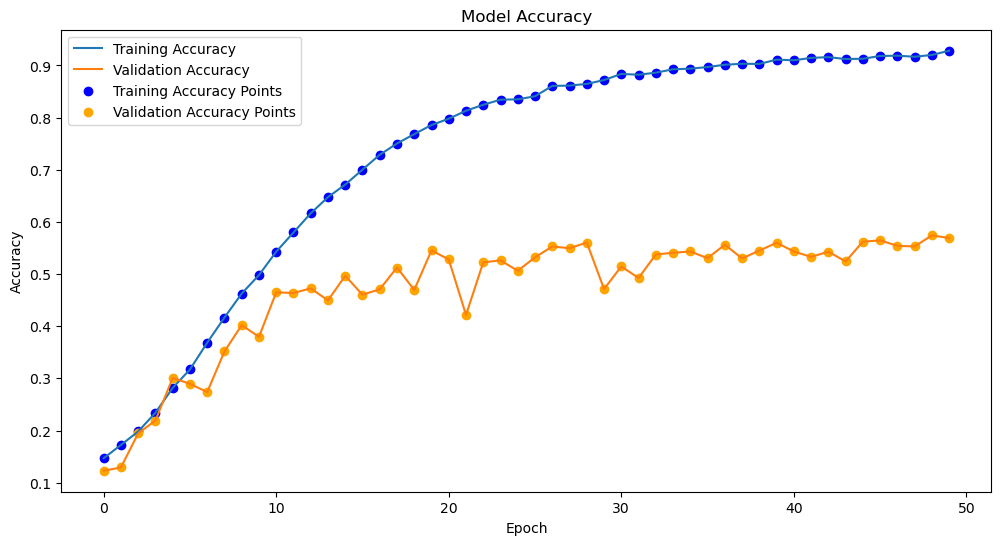

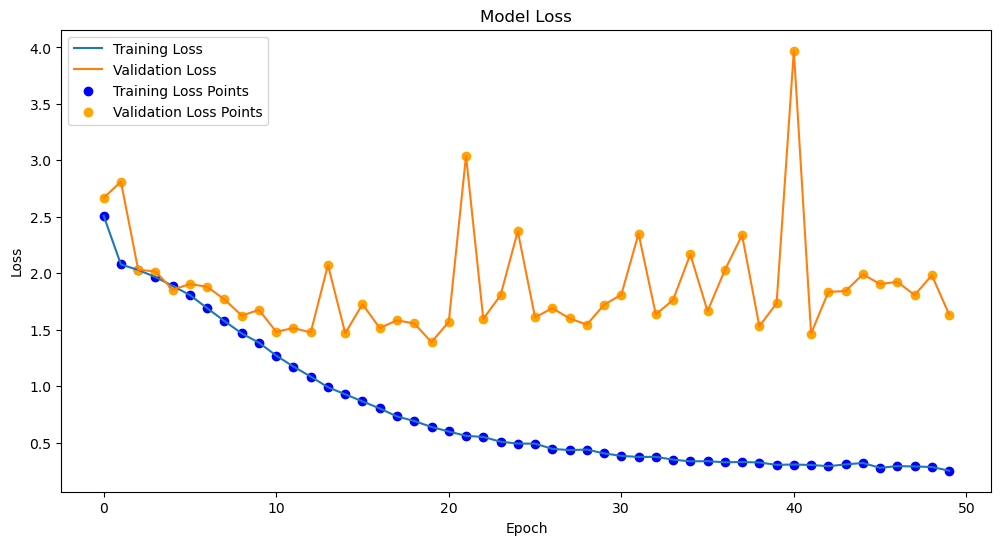

In [198]:
# Print the keys in the history object
print(ml_history.history.keys())

# Summarize history for accuracy
plt.figure(figsize=(12, 6))
plt.plot(ml_history.history['accuracy'], label="Training Accuracy")
plt.plot(ml_history.history['val_accuracy'], label="Validation Accuracy")
plt.scatter(range(len(ml_history.history['accuracy'])), ml_history.history['accuracy'], label="Training Accuracy Points", color='blue')
plt.scatter(range(len(ml_history.history['val_accuracy'])), ml_history.history['val_accuracy'], label="Validation Accuracy Points", color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Summarize history for loss
plt.figure(figsize=(12, 6))
plt.plot(ml_history.history['loss'], label="Training Loss")
plt.plot(ml_history.history['val_loss'], label="Validation Loss")
plt.scatter(range(len(ml_history.history['loss'])), ml_history.history['loss'], label="Training Loss Points", color='blue')
plt.scatter(range(len(ml_history.history['val_loss'])), ml_history.history['val_loss'], label="Validation Loss Points", color='orange')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

This code visualises the training and validation accuracy and loss over each epoch of the model's training process. First, it prints the keys of the `history` object to see available metrics. Then, it plots two graphs: one for **accuracy** (showing how well the model performed on both the training and validation sets) and one for **loss** (showing how the model's error decreased over time). It also adds scatter points to highlight individual epoch values for better insight into the model’s progress.

### Make Predictions:
Use the trained model to make predictions on unseen data.

In [200]:
def predict_image(filename, model):
    """
    Predict the class of an image using the given model and display it.

    Args:
        filename (str): Path to the image file.
        model (keras.Model): Trained model for making predictions.
    """
    # Load the image and resize it to the required input size for the model
    img_for_prediction = image.load_img(filename, target_size=(img_size))
    
    # Convert the image to an array and expand dimensions to match the model input
    img_array = image.img_to_array(img_for_prediction)
    img_processed = np.expand_dims(img_array, axis=0)
    
    # Normalize the image by scaling pixel values to [0, 1]
    img_processed /= 255.0

    # Make a prediction using the model
    prediction = model.predict(img_processed)
    
    # Get the class index with the highest prediction probability (add 1 for 1-based index)
    index = np.argmax(prediction) + 1

    # Load the image again for displaying, with proper size
    img_for_display = image.load_img(filename, target_size=(150, 150))
    img_display_array = image.img_to_array(img_for_display) / 255.0  # Normalize for display

    # Display the image with the prediction label
    plt.figure(figsize=(5, 5))
    plt.title("Prediction - {}".format(str(index).title()), size=18, color='red')  # Show predicted class as title
    plt.imshow(img_display_array)  # Display the image
    plt.axis('off')  # Turn off the axes for a clean view
    plt.show()  # Show the image


This code defines a function that takes an image file and a trained model as input, then makes a prediction on the image's class. It preprocesses the image (resizing, converting to an array, and normalizing), makes the prediction, and displays the image along with the predicted class label. The predicted label is shown as a title above the image for easy interpretation.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


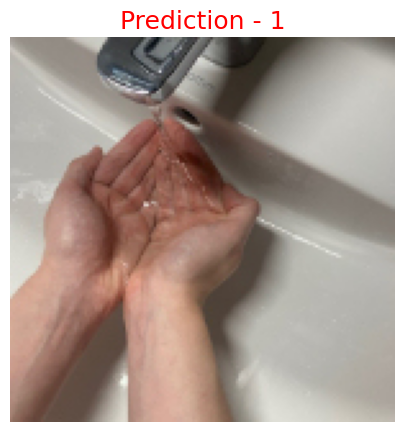

In [203]:
# Call the predict_image function with the specified image file and trained model
predict_image('CHS2406_Coursework2_Data_Repository/Stage1/1_stage_1_u2160151 (7).jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


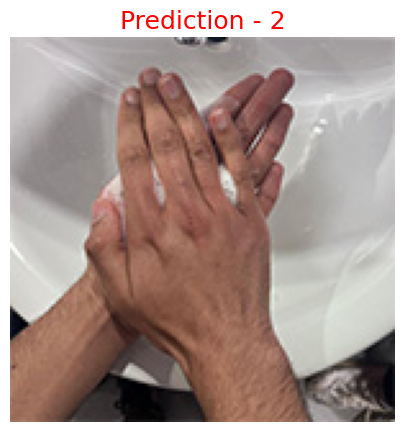

In [205]:
# Call the predict_image function with the path to an image from Stage 2 and the trained model
predict_image('CHS2406_Coursework2_Data_Repository/Stage2/Stage2_1_u2354188.jpg', model)
